<a href="https://colab.research.google.com/github/M-Khalid16/PhotonicsAILab_projects/blob/main/QAM_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Simulation of a Coherent Optical 16-QAM Fiber Communication System



## Problem Overview

In modern optical communication systems, digital data is transmitted using coherent detection and advanced modulation schemes where 16-QAM (Quadrature Amplitude Modulation)is gaining high importance. Sending high data rates (> 100 Gb/s) using this technique and receiving fully faithful data at the receiver end after long haul communication (say > 1000 km) is one of the greatest challanges to be solved in optical communications system.  This project implements a complete end-to-end simulation of a coherent optical communication link, starting from digital bits and ending with recovered bits after transmission through an optical fiber.

##  Objective

Simulate the following system:

$$
\text{Bits} \rightarrow \text{QAM Modulation} \rightarrow \text{Pulse Shaping} \rightarrow \text{Optical Channel} \rightarrow \text{Noise} \rightarrow \text{Receiver DSP} \rightarrow \text{Detection} \rightarrow \text{BER/SER}
$$



## System Description


A random binary sequence is generated:

$$
b \in \{0,1\}
$$


Bits are grouped into 4-bit symbols:

$$
(b_1, b_2, b_3, b_4)
$$

Each group is mapped to a complex symbol:

$$
s_k = I_k + jQ_k
$$

where $I_k, Q_k \in \{-3,-1,1,3\}$.

The constellation is normalized:

$$
s_k \leftarrow \frac{s_k}{\sqrt{\mathbb{E}[|s_k|^2]}}
$$



Discrete symbols are converted to a continuous waveform:

$$
x(t) = \sum_k s_k \, p(t - kT)
$$

where:
- $p(t)$ = Root Raised Cosine (RRC) filter
- $T$ = symbol period



The signal is scaled to desired launch power:

$$
A(t) = x(t) \cdot \sqrt{\frac{P_{\text{launch}}}{\mathbb{E}[|x(t)|^2]}}
$$


The optical field evolves according to the Nonlinear Schrödinger Equation (NLSE):

$$
\frac{\partial A}{\partial z}
=
-\frac{\alpha}{2}A
- j\frac{\beta_2}{2} \frac{\partial^2 A}{\partial t^2}
+ j\gamma |A|^2 A
$$

where:
- $\alpha$ = attenuation coefficient
- $\beta_2$ = chromatic dispersion
- $\gamma$ = Kerr nonlinearity

Numerically solved using the Split-Step Fourier Method (SSFM).



Add complex Gaussian noise:

$$
n(t) \sim \mathcal{CN}(0, \sigma^2)
$$

Received signal:

$$
r(t) = A(t) + n(t)
$$

Noise power:

$$
\sigma^2 = \frac{\mathbb{E}[|A(t)|^2]}{\text{SNR}}
$$



$$
y(t) = r(t) * p(t)
$$

$$
y[k] = y(t = kT)
$$


$$
y_k \leftarrow \frac{y_k}{\sqrt{\mathbb{E}[|y_k|^2]}}
$$


$$
\theta = \angle \left( \sum_k y_k s_k^* \right)
$$

$$
y_k \leftarrow y_k e^{j\theta}
$$


$$
\hat{s}_k = \arg\min_{c_i} |y_k - c_i|
$$


Symbols are mapped back to bits:

$$
\hat{b} = \text{demod}(\hat{s}_k)
$$


$$
\text{BER} = \frac{\text{Number of bit errors}}{\text{Total transmitted bits}}
$$


$$
\text{SER} = \frac{\text{Number of symbol errors}}{\text{Total symbols}}
$$



$$
\text{EVM} = \sqrt{
\frac{\mathbb{E}[|r_k - s_k|^2]}{\mathbb{E}[|s_k|^2]}
}
$$



The simulation should generate the following plots:



- First $N$ bits shown as digital waveform



- Transmitter constellation (with bit labels)
- Received constellation (before DSP)
- Received constellation (after DSP)



- RRC filter taps
- Time-domain waveform (I/Q components)



- Baseband signal power
- Optical envelope power
- Received power after fiber


$$
X(f) = \mathcal{F}\{x(t)\}
$$


- BER and SER bar plot


Implement a single function:

```python
simulate_qam_optical_fiber_link_with_plots(...)

In [ ]:
def simulate_qam_optical_fiber_link_with_plots(
    num_symbols=2048,
    snr_db=30,
    samples_per_symbol=8,
    symbol_rate_baud=32e9,
    rrc_beta=0.2,
    rrc_span_symbols=10,
    launch_power_watts=1e-3,
    fiber_length_km=40,
    alpha_db_per_km=0.2,
    beta2_ps2_per_km=-21.27,
    gamma_w_inv_km=1.3,
    num_ssfm_steps=20,
    seed=42,
    show_plots=True
):
    import numpy as np
    import matplotlib.pyplot as plt

    # ------------------------------------------------------------
    # Helper 1: 16-QAM constellation
    # ------------------------------------------------------------
    def generate_16qam_constellation():
        axis_map = {
            (0, 0): -3,
            (0, 1): -1,
            (1, 1):  1,
            (1, 0):  3,
        }

        mapping = {}
        for i_bits, i_level in axis_map.items():
            for q_bits, q_level in axis_map.items():
                bits = i_bits + q_bits
                mapping[bits] = i_level + 1j * q_level

        const = np.array(list(mapping.values()), dtype=complex)
        scale = np.sqrt(np.mean(np.abs(const) ** 2))

        const = const / scale
        mapping = {k: v / scale for k, v in mapping.items()}

        return const, mapping

    # ------------------------------------------------------------
    # Helper 2: QAM modulator
    # ------------------------------------------------------------
    def qam_modulate(bits, mapping):
        bits = np.asarray(bits, dtype=int)

        if len(bits) % 4 != 0:
            raise ValueError("Number of bits must be divisible by 4.")

        groups = bits.reshape((-1, 4))

        return np.array(
            [mapping[tuple(g)] for g in groups],
            dtype=complex
        )

    # ------------------------------------------------------------
    # Helper 3: QAM demodulator
    # ------------------------------------------------------------
    def qam_demodulate(received_symbols, constellation, mapping):
        reverse_mapping = {v: k for k, v in mapping.items()}

        distances = np.abs(
            received_symbols[:, None] - constellation[None, :]
        )

        nearest_indices = np.argmin(distances, axis=1)
        detected_symbols = constellation[nearest_indices]

        bits_rx = []
        for s in detected_symbols:
            bits_rx.extend(reverse_mapping[s])

        return detected_symbols, np.array(bits_rx, dtype=int)

    # ------------------------------------------------------------
    # Helper 4: RRC filter
    # ------------------------------------------------------------
    def root_raised_cosine_filter(beta, span_symbols, sps):
        n = span_symbols * sps
        t = np.arange(-n / 2, n / 2 + 1) / sps
        h = np.zeros_like(t, dtype=float)

        for k, tk in enumerate(t):
            if np.isclose(tk, 0):
                h[k] = 1 + beta * (4 / np.pi - 1)

            elif beta > 0 and np.isclose(abs(tk), 1 / (4 * beta)):
                h[k] = (
                    beta / np.sqrt(2)
                    * (
                        (1 + 2 / np.pi) * np.sin(np.pi / (4 * beta))
                        + (1 - 2 / np.pi) * np.cos(np.pi / (4 * beta))
                    )
                )

            else:
                numerator = (
                    np.sin(np.pi * tk * (1 - beta))
                    + 4 * beta * tk * np.cos(np.pi * tk * (1 + beta))
                )
                denominator = np.pi * tk * (1 - (4 * beta * tk) ** 2)
                h[k] = numerator / denominator

        h = h / np.sqrt(np.sum(h ** 2))
        return h

    # ------------------------------------------------------------
    # Helper 5: pulse shaping
    # ------------------------------------------------------------
    def pulse_shape_symbols(symbols, taps, sps):
        upsampled = np.zeros(len(symbols) * sps, dtype=complex)
        upsampled[::sps] = symbols

        full = np.convolve(upsampled, taps, mode="full")
        start = (len(taps) - 1) // 2
        end = start + len(upsampled)

        return full[start:end]

    # ------------------------------------------------------------
    # Helper 6: optical launch power scaling
    # ------------------------------------------------------------
    def generate_optical_envelope(waveform, launch_power):
        avg_power = np.mean(np.abs(waveform) ** 2)

        if avg_power == 0:
            raise ValueError("Waveform has zero power.")

        return waveform * np.sqrt(launch_power / avg_power)

    # ------------------------------------------------------------
    # Helper 7: fiber propagation using split-step Fourier method
    # ------------------------------------------------------------
    def fiber_propagate_ssfm(
        envelope,
        sample_rate_hz,
        fiber_length_km,
        alpha_db_per_km,
        beta2_ps2_per_km,
        gamma_w_inv_km,
        num_steps
    ):
        A = envelope.copy()

        if fiber_length_km == 0:
            return A

        alpha_np_per_km = alpha_db_per_km * np.log(10) / 10
        beta2_s2_per_km = beta2_ps2_per_km * 1e-24

        dz = fiber_length_km / num_steps

        n = len(A)
        freqs = np.fft.fftfreq(n, d=1 / sample_rate_hz)
        omega = 2 * np.pi * freqs

        linear_half_step = np.exp(
            (
                -alpha_np_per_km / 2
                + 1j * beta2_s2_per_km * omega ** 2 / 2
            )
            * dz / 2
        )

        for _ in range(num_steps):
            A = np.fft.ifft(np.fft.fft(A) * linear_half_step)

            A = A * np.exp(
                1j * gamma_w_inv_km * np.abs(A) ** 2 * dz
            )

            A = np.fft.ifft(np.fft.fft(A) * linear_half_step)

        return A

    # ------------------------------------------------------------
    # Helper 8: complex AWGN
    # ------------------------------------------------------------
    def add_complex_awgn(signal, snr_db, seed=None):
        rng = np.random.default_rng(seed)

        signal_power = np.mean(np.abs(signal) ** 2)
        snr_linear = 10 ** (snr_db / 10)
        noise_power = signal_power / snr_linear

        noise = np.sqrt(noise_power / 2) * (
            rng.standard_normal(len(signal))
            + 1j * rng.standard_normal(len(signal))
        )

        return signal + noise, noise_power

    # ------------------------------------------------------------
    # Helper 9: matched filter and downsampling
    # ------------------------------------------------------------
    def matched_filter_and_downsample(rx_waveform, taps, sps, n_symbols):
        filtered = np.convolve(rx_waveform, taps, mode="same")
        symbols = filtered[::sps]
        return symbols[:n_symbols]

    # ------------------------------------------------------------
    # Helper 10: receiver DSP
    # ------------------------------------------------------------
    def normalize_power(symbols):
        power = np.mean(np.abs(symbols) ** 2)
        return symbols / np.sqrt(power)

    def phase_correct(rx_symbols, tx_symbols):
        phase_error = np.angle(np.vdot(rx_symbols, tx_symbols))
        corrected = rx_symbols * np.exp(1j * phase_error)
        return corrected, phase_error

    # ------------------------------------------------------------
    # Helper 11: metrics
    # ------------------------------------------------------------
    def compute_metrics(bits_tx, bits_rx, symbols_tx, symbols_detected):
        bit_errors = int(np.sum(bits_tx != bits_rx))
        symbol_errors = int(np.sum(symbols_tx != symbols_detected))

        ber = bit_errors / len(bits_tx)
        ser = symbol_errors / len(symbols_tx)

        evm = np.sqrt(
            np.mean(np.abs(symbols_detected - symbols_tx) ** 2)
            / np.mean(np.abs(symbols_tx) ** 2)
        )

        return bit_errors, symbol_errors, ber, ser, evm

    # ------------------------------------------------------------
    # Helper 12: plots
    # ------------------------------------------------------------
    def plot_constellation(symbols, title, constellation=None):
        plt.figure(figsize=(6, 6))
        plt.scatter(symbols.real, symbols.imag, s=8, alpha=0.45)

        if constellation is not None:
            plt.scatter(
                constellation.real,
                constellation.imag,
                marker="x",
                s=100,
                label="Ideal constellation"
            )
            plt.legend()

        plt.axhline(0)
        plt.axvline(0)
        plt.grid(True)
        plt.axis("equal")
        plt.xlabel("In-phase, I")
        plt.ylabel("Quadrature, Q")
        plt.title(title)
        plt.show()

    def plot_power(waveform, title):
        plt.figure(figsize=(9, 3))
        plt.plot(np.abs(waveform) ** 2)
        plt.grid(True)
        plt.xlabel("Sample index")
        plt.ylabel("Power")
        plt.title(title)
        plt.show()

    def plot_spectrum(waveform, sample_rate, title):
        spectrum = np.fft.fftshift(np.fft.fft(waveform))
        freqs = np.fft.fftshift(
            np.fft.fftfreq(len(waveform), d=1 / sample_rate)
        )

        plt.figure(figsize=(9, 3))
        plt.plot(freqs / 1e9, 20 * np.log10(np.abs(spectrum) + 1e-12))
        plt.grid(True)
        plt.xlabel("Frequency offset (GHz)")
        plt.ylabel("Magnitude (dB)")
        plt.title(title)
        plt.show()

    # ============================================================
    # Main simulation starts here
    # ============================================================

    rng = np.random.default_rng(seed)
    bits_per_symbol = 4

    sample_rate_hz = symbol_rate_baud * samples_per_symbol

    # Stage 1: bits
    bits_tx = rng.integers(
        low=0,
        high=2,
        size=num_symbols * bits_per_symbol
    )

    # Stage 2: QAM modulation
    constellation, mapping = generate_16qam_constellation()
    symbols_tx = qam_modulate(bits_tx, mapping)

    # Stage 3: pulse shaping
    rrc_taps = root_raised_cosine_filter(
        beta=rrc_beta,
        span_symbols=rrc_span_symbols,
        sps=samples_per_symbol
    )

    tx_waveform = pulse_shape_symbols(
        symbols_tx,
        rrc_taps,
        samples_per_symbol
    )

    # Stage 4: optical envelope
    optical_envelope_tx = generate_optical_envelope(
        tx_waveform,
        launch_power_watts
    )

    # Stage 5: fiber propagation
    optical_envelope_fiber = fiber_propagate_ssfm(
        envelope=optical_envelope_tx,
        sample_rate_hz=sample_rate_hz,
        fiber_length_km=fiber_length_km,
        alpha_db_per_km=alpha_db_per_km,
        beta2_ps2_per_km=beta2_ps2_per_km,
        gamma_w_inv_km=gamma_w_inv_km,
        num_steps=num_ssfm_steps
    )

    # Stage 6: receiver noise
    optical_envelope_rx, noise_power = add_complex_awgn(
        optical_envelope_fiber,
        snr_db=snr_db,
        seed=seed
    )

    # Stage 7: matched filtering and downsampling
    symbols_rx_raw = matched_filter_and_downsample(
        optical_envelope_rx,
        rrc_taps,
        samples_per_symbol,
        num_symbols
    )

    # Stage 8: DSP
    symbols_rx_norm = normalize_power(symbols_rx_raw)
    symbols_rx_dsp, phase_error = phase_correct(
        symbols_rx_norm,
        symbols_tx
    )

    # Stage 9: detection
    symbols_detected, bits_rx = qam_demodulate(
        symbols_rx_dsp,
        constellation,
        mapping
    )

    # Stage 10: metrics
    bit_errors, symbol_errors, ber, ser, evm = compute_metrics(
        bits_tx,
        bits_rx,
        symbols_tx,
        symbols_detected
    )

    # ============================================================
    # Plots
    # ============================================================

    if show_plots:
        plot_constellation(
            symbols_tx,
            "Stage 1: Transmitted 16-QAM Symbols",
            constellation
        )

        plt.figure(figsize=(8, 3))
        plt.plot(rrc_taps)
        plt.grid(True)
        plt.xlabel("Tap index")
        plt.ylabel("Amplitude")
        plt.title("Stage 2: Root-Raised-Cosine Pulse-Shaping Filter")
        plt.show()

        plot_power(
            tx_waveform,
            "Stage 3: Pulse-Shaped Electrical/Baseband Waveform Power"
        )

        plot_spectrum(
            tx_waveform,
            sample_rate_hz,
            "Stage 3: Spectrum of Pulse-Shaped Signal"
        )

        plot_power(
            optical_envelope_tx,
            "Stage 4: Optical Envelope at Transmitter"
        )

        plot_power(
            optical_envelope_fiber,
            f"Stage 5: Optical Envelope After {fiber_length_km} km Fiber"
        )

        plot_spectrum(
            optical_envelope_fiber,
            sample_rate_hz,
            "Stage 5: Spectrum After Fiber Propagation"
        )

        plot_power(
            optical_envelope_rx,
            "Stage 6: Received Optical Envelope With Noise"
        )

        plot_constellation(
            symbols_rx_raw,
            "Stage 7: Raw Received Symbols Before DSP",
            constellation
        )

        plot_constellation(
            symbols_rx_dsp,
            "Stage 8: Symbols After DSP",
            constellation
        )

        plot_constellation(
            symbols_detected,
            "Stage 9: Final Detected Symbols",
            constellation
        )

        plt.figure(figsize=(5, 3))
        plt.bar(["BER", "SER"], [ber, ser])
        plt.grid(True, axis="y")
        plt.ylabel("Error rate")
        plt.title("Stage 10: Final Error Rates")
        plt.show()

    # ============================================================
    # Return all useful results
    # ============================================================

    return {
        "bits_tx": bits_tx,
        "bits_rx": bits_rx,

        "symbols_tx": symbols_tx,
        "symbols_rx_raw": symbols_rx_raw,
        "symbols_rx_dsp": symbols_rx_dsp,
        "symbols_detected": symbols_detected,

        "constellation": constellation,
        "rrc_taps": rrc_taps,

        "tx_waveform": tx_waveform,
        "optical_envelope_tx": optical_envelope_tx,
        "optical_envelope_fiber": optical_envelope_fiber,
        "optical_envelope_rx": optical_envelope_rx,

        "bit_errors": bit_errors,
        "symbol_errors": symbol_errors,
        "bit_error_rate": ber,
        "symbol_error_rate": ser,
        "evm_rms": evm,
        "evm_percent": 100 * evm,

        "noise_power": noise_power,
        "phase_error_rad": phase_error,

        "sample_rate_hz": sample_rate_hz,
        "symbol_rate_baud": symbol_rate_baud,
        "samples_per_symbol": samples_per_symbol,
        "fiber_length_km": fiber_length_km,
        "launch_power_watts": launch_power_watts,
        "snr_db": snr_db,
    }



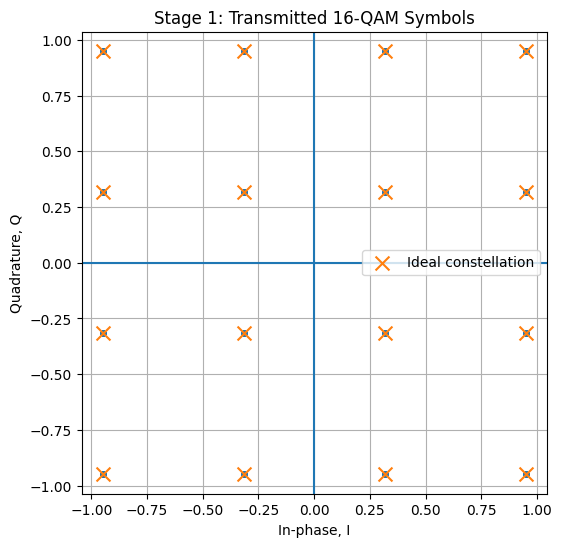

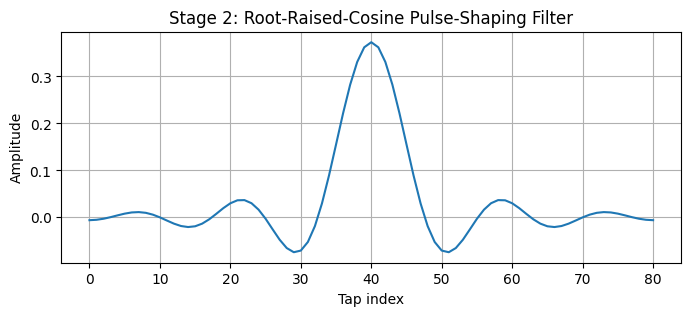

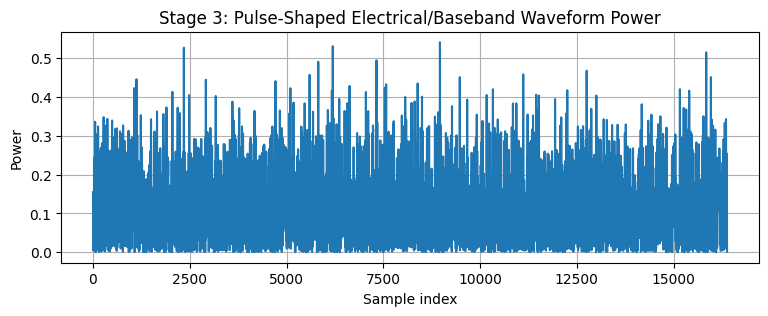

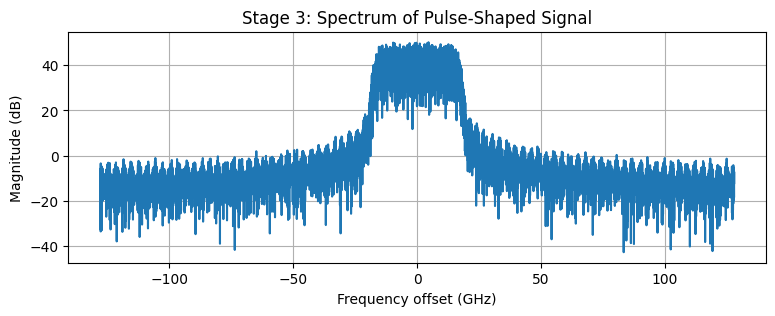

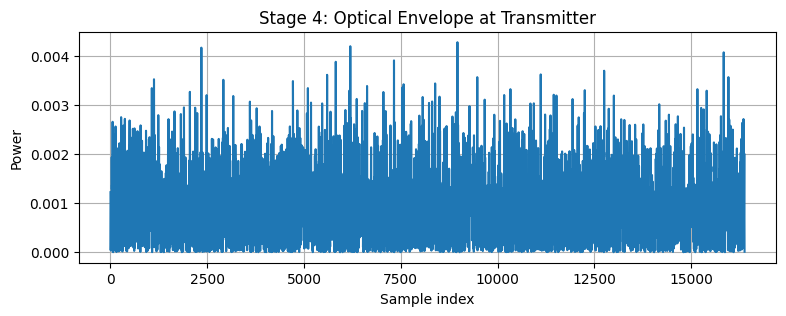

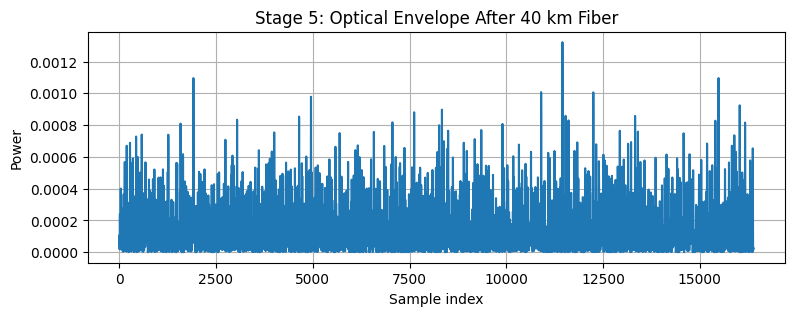

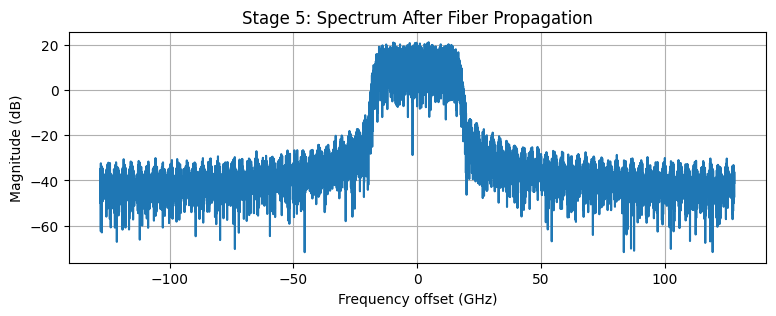

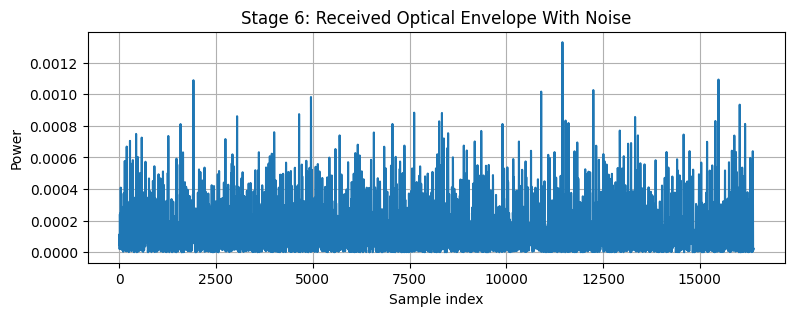

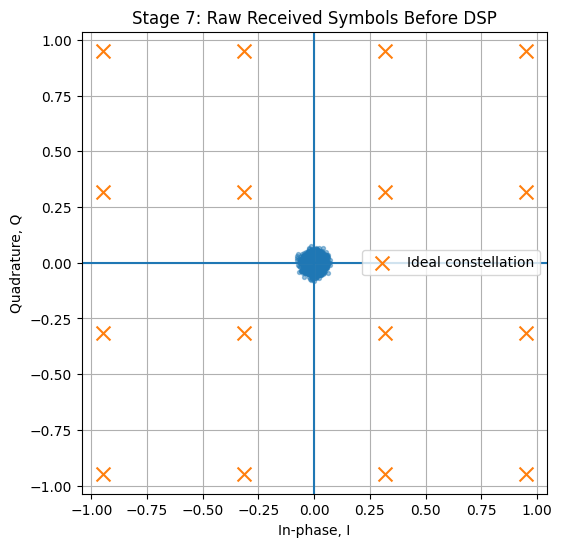

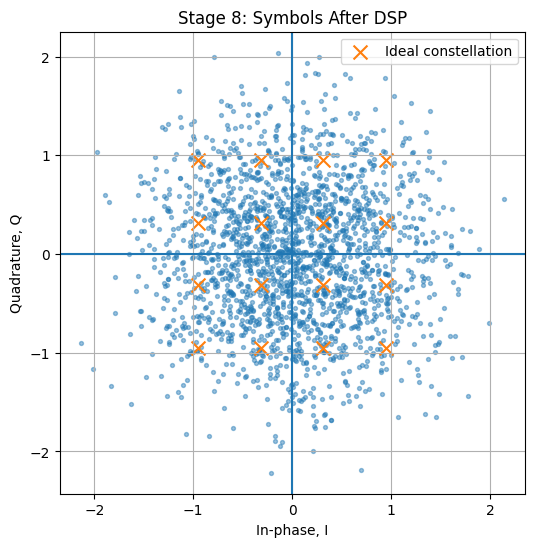

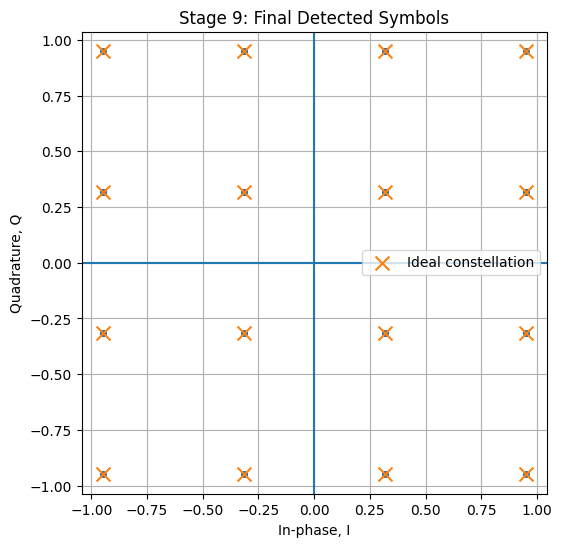

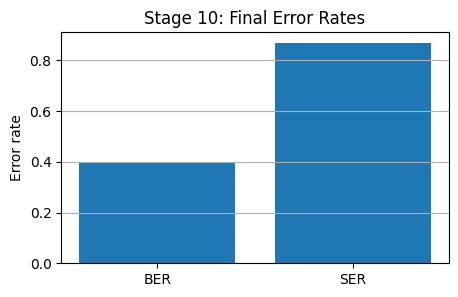

BER: 0.4000244140625
SER: 0.86767578125
EVM (%): 103.56185593470393


In [ ]:
result = simulate_qam_optical_fiber_link_with_plots(
    num_symbols=2048,
    snr_db=30,
    samples_per_symbol=8,
    symbol_rate_baud=32e9,
    fiber_length_km=40,
    launch_power_watts=1e-3,
    seed=42,
    show_plots=True
)

print("BER:", result["bit_error_rate"])
print("SER:", result["symbol_error_rate"])
print("EVM (%):", result["evm_percent"])